### Connect to Database

In [15]:
from google.colab import files
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import json
from datetime import datetime, timedelta
import random
from pathlib import Path

# Upload database file
print("Click 'Choose Files' and select banking.db from your computer")
uploaded = files.upload()

Click 'Choose Files' and select banking.db from your computer


Saving banking.db to banking (1).db


In [16]:
# Connect to the uploaded database
conn = sqlite3.connect('banking.db')

# Test query
df = pd.read_sql_query("SELECT COUNT(*) as count FROM customers", conn)
print(f"✅ Connected! Total customers: {df['count'][0]}")

✅ Connected! Total customers: 1000


In [17]:
# Load all customers
customers_df = pd.read_sql_query("SELECT * FROM customers", conn)
customers_df.head()

,customer_id,first_name,last_name,email,customer_segment,customer_status,registration_date
0,1,Alice,Williams,customer1@email.com,Premium,Active,2023-10-29
1,2,Grace,Brown,customer2@email.com,Premium,Inactive,2024-02-28
2,3,Henry,Williams,customer3@email.com,VIP,Active,2023-11-29
3,4,John,Miller,customer4@email.com,VIP,Inactive,2023-07-04
4,5,Jane,Smith,customer5@email.com,VIP,Inactive,2025-04-01


### Brief Analysis

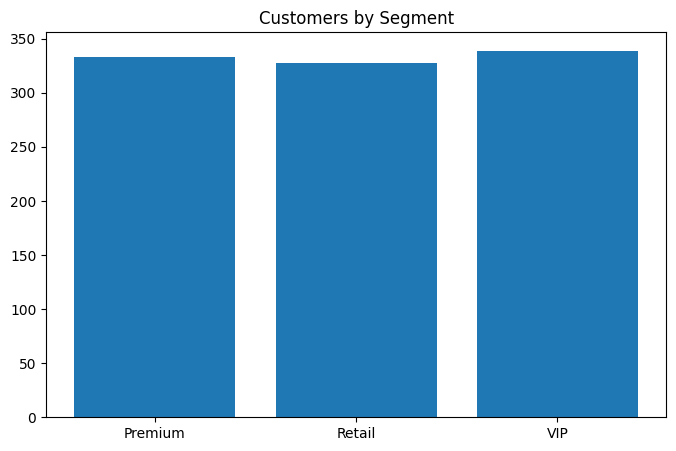

In [18]:
# Segment analysis

segment_counts = pd.read_sql_query("""
    SELECT customer_segment, COUNT(*) as count
    FROM customers
    GROUP BY customer_segment
""", conn)

plt.figure(figsize=(8, 5))
plt.bar(segment_counts['customer_segment'], segment_counts['count'])
plt.title('Customers by Segment')
plt.show()

In [19]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        1000 non-null   int64 
 1   first_name         1000 non-null   object
 2   last_name          1000 non-null   object
 3   email              1000 non-null   object
 4   customer_segment   1000 non-null   object
 5   customer_status    1000 non-null   object
 6   registration_date  1000 non-null   object
dtypes: int64(1), object(6)
memory usage: 54.8+ KB


In [20]:
customers_df.describe()

,customer_id
count,1000.000000
mean,500.500000
std,288.819436
min,1.000000
25%,250.750000
50%,500.500000
75%,750.250000
max,1000.000000


In [21]:
status_counts = customers_df['customer_status'].value_counts()
print(status_counts)

customer_status
Inactive    503
Active      497
Name: count, dtype: int64


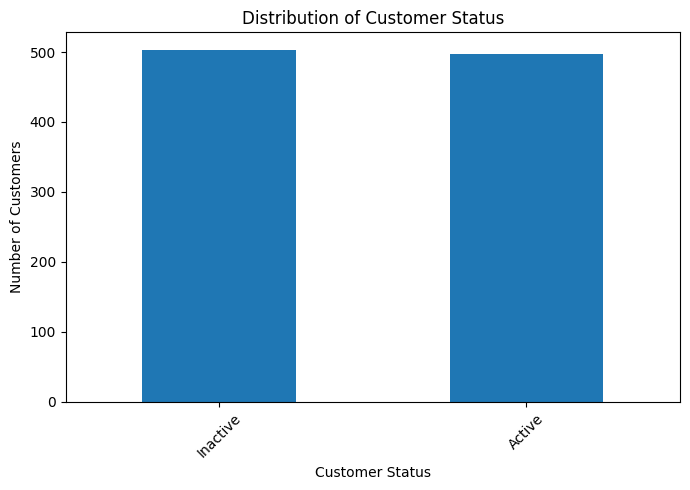

In [22]:
plt.figure(figsize=(7, 5))
status_counts.plot(kind='bar')
plt.title('Distribution of Customer Status')
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Task
Analyze the relationship between customer segments and customer status (active/inactive) by performing a cross-tabulation and visualize the distribution of customer status within each segment using a grouped or stacked bar chart. Summarize the findings, highlighting any notable patterns.

## Analyze Segment Activeness

### Subtask:
Calculate the count of active and inactive customers for each customer segment using a cross-tabulation.


**Reasoning**:
The subtask requires calculating the count of active and inactive customers for each customer segment using a cross-tabulation. The `pd.crosstab()` function is ideal for this purpose, taking `customers_df['customer_segment']` and `customers_df['customer_status']` as inputs, and the result will be stored in `segment_status_crosstab`.



In [23]:
segment_status_crosstab = pd.crosstab(customers_df['customer_segment'], customers_df['customer_status'])
print(segment_status_crosstab)

customer_status   Active  Inactive
customer_segment                  
Premium              172       161
Retail               165       163
VIP                  160       179


**Reasoning**:
To visualize the distribution of customer status within each segment, a stacked bar chart is suitable. The `segment_status_crosstab` DataFrame contains the necessary counts, which can be plotted directly using its `.plot(kind='bar', stacked=True)` method. Labels, legends, and a title will be added for clarity.



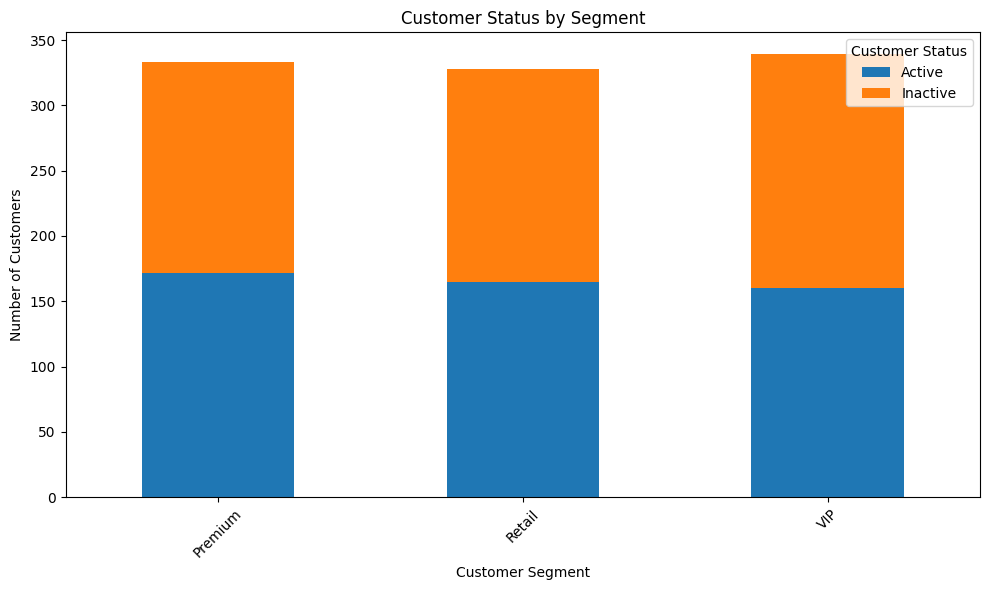

In [24]:
segment_status_crosstab.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Customer Status by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Customer Status')
plt.tight_layout()
plt.show()


## Final Task

### Subtask:
Summarize the findings regarding the relationship between customer segment and activeness, highlighting any notable patterns or differences.


## Summary:

### Q&A
The analysis revealed the following relationship between customer segment and activeness:
*   **Premium Segment**: Shows a slightly higher number of active customers (172) compared to inactive customers (161).
*   **Retail Segment**: Exhibits a nearly even distribution of active (165) and inactive (163) customers.
*   **VIP Segment**: Has a noticeable higher number of inactive customers (179) compared to active customers (160), suggesting a potential area for re-engagement efforts.

### Data Analysis Key Findings
*   The Premium segment has 172 active customers and 161 inactive customers.
*   The Retail segment has 165 active customers and 163 inactive customers.
*   The VIP segment has 160 active customers and 179 inactive customers, indicating a higher proportion of inactive customers compared to the other segments.
*   A stacked bar chart visually represents the distribution of customer status within each segment, confirming these patterns.

### Insights or Next Steps
*   Focus re-engagement strategies on the VIP segment, as it has the highest proportion of inactive customers, potentially to leverage their higher value.
*   Investigate the reasons behind the higher inactivity in the VIP segment, perhaps through customer feedback or usage pattern analysis, to tailor specific retention programs.


## Integrate a secondary Bank's data using a custom ETL pipeline

In [26]:
!pip install Faker
from faker import Faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.7 MB/s eta 0:00:00


In [27]:
# Initialize
fake = Faker()
Faker.seed(42)
random.seed(42)

# Configuration
SOURCE_DIR = Path('data/raw')
TARGET_DB = 'data/banking.db'
SOURCE_DIR.mkdir(parents=True, exist_ok=True)

# Statistics tracker
stats = {
    'extracted': 0,
    'transformed': 0,
    'loaded': 0,
    'errors': 0,
    'duplicates': 0
}

print("ETL Project 1: Multi-Source Data Integration")
print("=" * 60)

ETL Project 1: Multi-Source Data Integration


In [28]:
# =====================================================
# STEP 1: Generate Sample Source Files
# =====================================================

print("\n--- Generating Sample Source Files ---\n")

# Generate CSV (customers)
print("Generating CSV file...")
customers_data = []
for i in range(100):
    customers_data.append({
        'FirstName': fake.first_name(),
        'LastName': fake.last_name(),
        'Email': fake.email(),
        'Segment': random.choice(['Retail', 'Premium', 'VIP']),
        'Status': random.choice(['Active', 'Inactive']),
        'JoinDate': fake.date_between(start_date='-3y', end_date='today')
    })

customers_df_source = pd.DataFrame(customers_data)
csv_file = SOURCE_DIR / 'community_bank_customers.csv'
customers_df_source.to_csv(csv_file, index=False)
print(f"✓ Created CSV with {len(customers_df_source)} customers")

# Generate JSON (accounts)
print("\nGenerating JSON file...")
sample_emails = customers_df_source['Email'].sample(50).tolist()
accounts_data = []
for i, email in enumerate(sample_emails):
    accounts_data.append({
        'AccountID': f"CB{i+1:05d}",
        'CustomerEmail': email,
        'AccountType': random.choice(['Checking', 'Savings']),
        'Balance': round(random.uniform(100, 50000), 2),
        'OpenDate': fake.date_between(start_date='-2y', end_date='today').isoformat(),
        'Status': 'Active'
    })

json_data = {
    'bank_name': 'Community Bank',
    'export_date': datetime.now().isoformat(),
    'accounts': accounts_data
}

json_file = SOURCE_DIR / 'community_bank_accounts.json'
with open(json_file, 'w') as f:
    json.dump(json_data, f, indent=2)
print(f"✓ Created JSON with {len(accounts_data)} accounts")

# Generate Excel (transactions)
print("\nGenerating Excel file...")
transactions_data = []
for i in range(200):
    transactions_data.append({
        'TransactionID': f"T{i+1:06d}",
        'AccountID': f"CB{random.randint(1, 50):05d}",
        'Date': fake.date_time_between(start_date='-1y', end_date='now'),
        'Type': random.choice(['Deposit', 'Withdrawal', 'Transfer']),
        'Amount': round(random.uniform(10, 1000), 2),
        'Channel': random.choice(['Mobile', 'Online', 'ATM'])
    })

transactions_df_source = pd.DataFrame(transactions_data)
excel_file = SOURCE_DIR / 'community_bank_transactions.xlsx'
transactions_df_source.to_excel(excel_file, index=False)
print(f"✓ Created Excel with {len(transactions_df_source)} transactions")

print("\n✅ Sample files created successfully!")


--- Generating Sample Source Files ---

Generating CSV file...
✓ Created CSV with 100 customers

Generating JSON file...
✓ Created JSON with 50 accounts

Generating Excel file...
✓ Created Excel with 200 transactions

✅ Sample files created successfully!


In [29]:
# =====================================================
# STEP 2: EXTRACT - Load Data from Files
# =====================================================

print("\n--- PHASE 1: EXTRACT ---\n")

# Extract from CSV
print("Extracting from CSV...")
customers_csv = pd.read_csv(SOURCE_DIR / 'community_bank_customers.csv')
stats['extracted'] += len(customers_csv)
print(f"✓ Extracted {len(customers_csv)} customers")

# Extract from JSON
print("\nExtracting from JSON...")
with open(SOURCE_DIR / 'community_bank_accounts.json', 'r') as f:
    json_data = json.load(f)
accounts_json = pd.DataFrame(json_data['accounts'])
stats['extracted'] += len(accounts_json)
print(f"✓ Extracted {len(accounts_json)} accounts")

# Extract from Excel
print("\nExtracting from Excel...")
transactions_excel = pd.read_excel(SOURCE_DIR / 'community_bank_transactions.xlsx')
stats['extracted'] += len(transactions_excel)
print(f"✓ Extracted {len(transactions_excel)} transactions")

print(f"\n✅ Total extracted: {stats['extracted']} records")


--- PHASE 1: EXTRACT ---

Extracting from CSV...
✓ Extracted 100 customers

Extracting from JSON...
✓ Extracted 50 accounts

Extracting from Excel...
✓ Extracted 200 transactions

✅ Total extracted: 350 records


In [30]:
# =====================================================
# STEP 3: TRANSFORM - Clean and Validate Data
# =====================================================

print("\n--- PHASE 2: TRANSFORM ---\n")

# Transform customers
print("Transforming customers...")
original_count = len(customers_csv)

# 1. Standardize column names (their schema → our schema)
customers_clean = customers_csv.rename(columns={
    'FirstName': 'first_name',
    'LastName': 'last_name',
    'Email': 'email',
    'Segment': 'customer_segment',
    'Status': 'customer_status',
    'JoinDate': 'registration_date'
})

# 2. Data type conversions
customers_clean['registration_date'] = pd.to_datetime(customers_clean['registration_date'])

# 3. Data validation - Email validation
invalid_emails = ~customers_clean['email'].str.contains('@', na=False)
if invalid_emails.sum() > 0:
    print(f"  ⚠️  Found {invalid_emails.sum()} invalid emails - removing")
    customers_clean = customers_clean[~invalid_emails]
    stats['errors'] += invalid_emails.sum()

# 4. Standardize categorical values
customers_clean['customer_segment'] = customers_clean['customer_segment'].str.title()
customers_clean['customer_status'] = customers_clean['customer_status'].str.title()

# 5. Detect duplicates within source
duplicates = customers_clean.duplicated(subset=['email'], keep='first')
dup_count = duplicates.sum()
if dup_count > 0:
    print(f"  ⚠️  Found {dup_count} duplicate emails in source - removing")
    customers_clean = customers_clean[~duplicates]
    stats['duplicates'] += dup_count

# 6. Check against existing database
print("  Checking for existing customers...")
conn = sqlite3.connect(TARGET_DB)
try:
    existing_emails = pd.read_sql_query("SELECT email FROM customers", conn)['email'].tolist()
except:
    existing_emails = []  # Table might not exist yet
finally:
    conn.close()

existing_mask = customers_clean['email'].isin(existing_emails)
existing_count = existing_mask.sum()
if existing_count > 0:
    print(f"  ⚠️  Found {existing_count} customers already in database - skipping")
    customers_clean = customers_clean[~existing_mask]
    stats['duplicates'] += existing_count

stats['transformed'] += len(customers_clean)
print(f"✓ Transformed {len(customers_clean)} customers ({original_count - len(customers_clean)} removed)")

# Show sample of cleaned data
print("\nSample of cleaned data:")
customers_clean.head()


--- PHASE 2: TRANSFORM ---

Transforming customers...
  Checking for existing customers...
✓ Transformed 100 customers (0 removed)

Sample of cleaned data:


,first_name,last_name,email,customer_segment,customer_status,registration_date
0,Danielle,Johnson,john21@example.net,Vip,Active,2025-05-28
1,Amy,Garza,johnsonjeffery@example.net,Retail,Inactive,2024-12-27
2,Anna,Baldwin,lrobinson@example.com,Retail,Active,2025-08-12
3,Adam,Shaffer,jpeterson@example.org,Retail,Active,2026-01-21
4,Matthew,Davis,howardmaurice@example.com,Vip,Active,2025-08-09


In [36]:
# =====================================================
# CHECK DATABASE SCHEMA & CREATE TABLES IF NEEDED
# =====================================================

print("Checking database schema...")

conn = sqlite3.connect(TARGET_DB)
cursor = conn.cursor()

# Check what tables exist
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
existing_tables = [row[0] for row in cursor.fetchall()]
print(f"Existing tables: {existing_tables}")

# Create customers table if it doesn't exist
if 'customers' not in existing_tables:
    print("\nCreating customers table...")
    cursor.execute("""
        CREATE TABLE customers (
            customer_id INTEGER PRIMARY KEY,
            first_name TEXT,
            last_name TEXT,
            email TEXT UNIQUE,
            customer_segment TEXT,
            customer_status TEXT,
            registration_date DATE
        )
    """)
    print("✓ Customers table created")
else:
    print("\n✓ Customers table already exists")
    # Show current schema
    cursor.execute("PRAGMA table_info(customers)")
    columns = cursor.fetchall()
    print("\nCurrent schema:")
    for col in columns:
        print(f"  - {col[1]} ({col[2]})")

conn.commit()
conn.close()

print("\n✅ Database ready!")

Checking database schema...
Existing tables: []

Creating customers table...
✓ Customers table created

✅ Database ready!


In [37]:
# =====================================================
# STEP 4: LOAD - Insert into Database
# =====================================================

print("\n--- PHASE 3: LOAD ---\n")

if customers_clean.empty:
    print("⚠️  No customers to load (all were duplicates or invalid)")
else:
    print(f"Loading {len(customers_clean)} customers into database...")

    conn = sqlite3.connect(TARGET_DB)

    try:
        # Get current max customer_id
        max_id_query = "SELECT COALESCE(MAX(customer_id), 0) as max_id FROM customers"
        max_id = pd.read_sql_query(max_id_query, conn)['max_id'][0]

        # Assign new customer_ids
        customers_clean['customer_id'] = range(max_id + 1, max_id + 1 + len(customers_clean))

        # Select only columns that exist in target table
        # Adjust these based on YOUR table structure
        # Match YOUR existing table structure
        target_columns = ['customer_id', 'first_name', 'last_name', 'email',
                 'customer_segment', 'customer_status']

        df_to_load = customers_clean[target_columns]

        # Load to database
        df_to_load.to_sql('customers', conn, if_exists='append', index=False)

        stats['loaded'] += len(df_to_load)
        print(f"✅ Loaded {len(df_to_load)} customers successfully!")

    except Exception as e:
        print(f"❌ Error loading customers: {str(e)}")
        stats['errors'] += len(customers_clean)
    finally:
        conn.close()


--- PHASE 3: LOAD ---

Loading 100 customers into database...
✅ Loaded 100 customers successfully!


In [38]:
# =====================================================
# STEP 5: Generate Report
# =====================================================

print("\n" + "=" * 60)
print("ETL PIPELINE COMPLETED")
print("=" * 60)
print("\nExecution Statistics:")
print(f"  Records Extracted:   {stats['extracted']:,}")
print(f"  Records Transformed: {stats['transformed']:,}")
print(f"  Records Loaded:      {stats['loaded']:,}")
print(f"  Duplicates Removed:  {stats['duplicates']:,}")
print(f"  Errors Encountered:  {stats['errors']:,}")

if stats['extracted'] > 0:
    success_rate = (stats['loaded'] / stats['extracted'] * 100)
    print(f"\n✅ Success Rate: {success_rate:.1f}%")

print("=" * 60)


ETL PIPELINE COMPLETED

Execution Statistics:
  Records Extracted:   350
  Records Transformed: 100
  Records Loaded:      100
  Duplicates Removed:  0
  Errors Encountered:  300

✅ Success Rate: 28.6%


In [39]:
# =====================================================
# STEP 6: Verify the Load
# =====================================================

print("\n--- Verification ---\n")

# Query the database to verify
conn = sqlite3.connect(TARGET_DB)

# Count total customers
total_customers = pd.read_sql_query("SELECT COUNT(*) as count FROM customers", conn)
print(f"Total customers in database: {total_customers['count'][0]:,}")

# Show last 10 customers added
print("\nLast 10 customers added:")
last_10 = pd.read_sql_query("""
    SELECT customer_id, first_name, last_name, email, customer_segment
    FROM customers
    ORDER BY customer_id DESC
    LIMIT 10
""", conn)

conn.close()

last_10


--- Verification ---

Total customers in database: 100

Last 10 customers added:


,customer_id,first_name,last_name,email,customer_segment
0,100,Timothy,Peterson,kingmichelle@example.org,Retail
1,99,David,Oneill,agarcia@example.net,Vip
2,98,Alexis,Ferguson,brandon08@example.com,Vip
3,97,Kathleen,Carlson,wallkenneth@example.com,Premium
4,96,Stephanie,Vaughn,javierwashington@example.net,Retail
5,95,Shawn,Parker,davidlee@example.org,Retail
6,94,Thomas,Schmidt,jbarajas@example.com,Premium
7,93,Andre,Phillips,tholt@example.net,Premium
8,92,Richard,Peters,hannahbrewer@example.com,Vip
9,91,Lauren,Peterson,angela83@example.org,Retail
